# DP

Génération de la matrice de transition...
Exécution de Value Iteration...


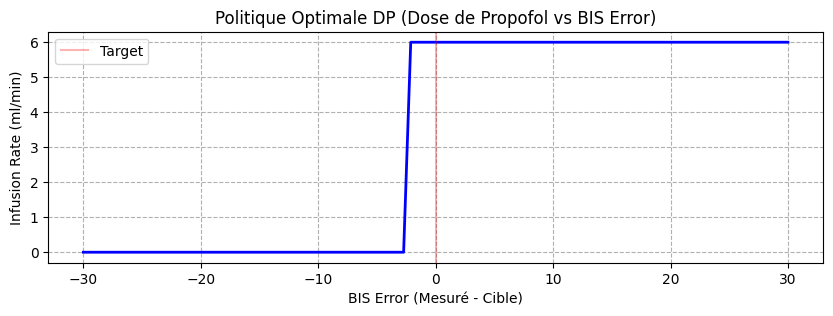

Evaluating policy for 100000 episodes, each 120 steps (5s per step)...


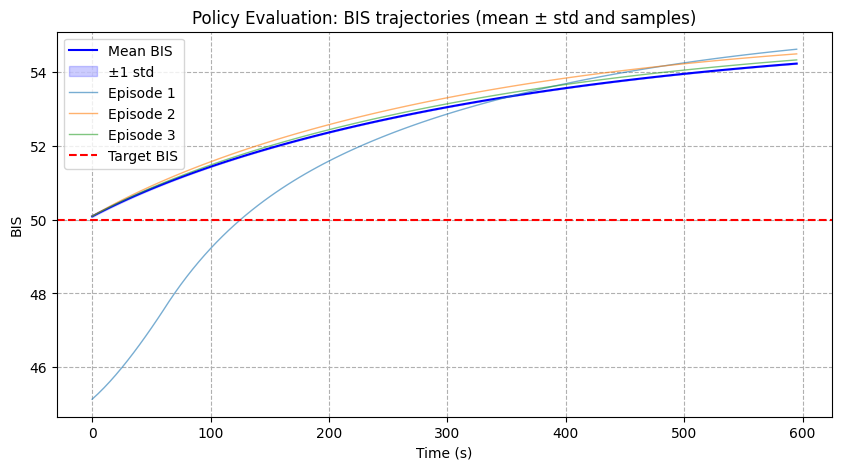

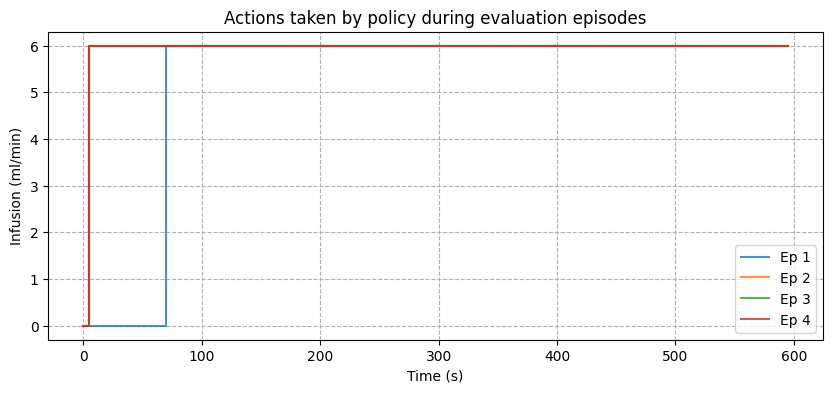

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURATION PK/PD (Modèle de Schnider) ---
V1, V2, V3 = 4.27, 18.9, 238.0
k10, k12, k21, k13, k31 = 0.38, 0.30, 0.20, 0.19, 0.0035
ke0 = 0.17  # Constante de transfert vers le site d'effet [8]

# Paramètres PD (Equation de Hill pour le BIS)
BIS_0, BIS_MAX, EC50, HILL = 95.0, 75.0, 3.5, 2.5 # [9]
BIS_TARGET = 50.0

# --- CONFIGURATION RL ---
ACTIONS = [0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 6.0] # Version réduite pour le calcul [10]
GAMMA = 0.69 # Facteur de remise [11]
BINS_PER_FEAT = 10
NUM_STATES = BINS_PER_FEAT**3 # 3 fonctions floues (N, Z, P)

def get_fuzzy_features(error):
    """Fuzzification de BISerror selon Moore et al. (Fig 1)"""
    x = 20.0 # Échelle de l'erreur
    v = np.clip(error / x, -1, 1)
    mu_n = max(0, -v)
    mu_p = max(0, v)
    mu_z = max(0, 1 - abs(v))
    return np.array([mu_n, mu_z, mu_p])

def state_to_idx(features):
    """Map the 3D fuzzy feature vector to an integer index in 0..NUM_STATES-1.

    Encode bins in base `BINS_PER_FEAT`: index = b0*BINS_PER_FEAT^2 + b1*BINS_PER_FEAT + b2
    """
    features = np.asarray(features)
    if features.shape != (3,):
        raise ValueError(f"features must be length-3 vector, got shape {features.shape}")
    # discretize to 0..BINS_PER_FEAT-1 safely
    bins = np.clip((features * (BINS_PER_FEAT - 1)), 0, BINS_PER_FEAT - 1).astype(int)
    # encode in base BINS_PER_FEAT
    idx = int(bins[0] * (BINS_PER_FEAT**2) + bins[1] * BINS_PER_FEAT + bins[2])
    return idx

def get_ce_from_error(error):
    """Inverse de la fonction PD pour estimer Ce à partir du BIS"""
    bis = error + BIS_TARGET
    # Inversion de BIS = BIS_0 - BIS_MAX * (Ce^H / (Ce^H + EC50^H))
    ratio = (BIS_0 - bis) / BIS_MAX
    ratio = np.clip(ratio, 0.01, 0.99)
    ce = EC50 * (ratio / (1 - ratio))**(1/HILL)
    return ce

# 1. GÉNÉRATION DE LA MATRICE DE TRANSITION (World Model)
print("Génération de la matrice de transition...")
P = np.zeros((NUM_STATES, len(ACTIONS)), dtype=int)
R = np.zeros((NUM_STATES, len(ACTIONS)))

# On itère sur une plage réaliste d'erreurs pour remplir la table
for err in np.linspace(-40, 40, 1000):
    feat = get_fuzzy_features(err)
    s = state_to_idx(feat)
    ce_init = get_ce_from_error(err)

    for a_idx, infusion in enumerate(ACTIONS):
        # Simulation Schnider (pas de 5s) [14]
        dt = 5/60
        ce_next = ce_init + ke0 * (ce_init - ce_init) * dt # Simplification Euler
        # En réalité, le mouvement dépend de la concentration centrale C1
        # Pour DP, on simule l'effet direct de l'infusion sur Ce
        ce_next += (infusion / V1) * dt * 0.1 # Approximation de l'impact dose

        bis_next = BIS_0 - BIS_MAX * (ce_next**HILL / (ce_next**HILL + EC50**HILL))
        err_next = bis_next - BIS_TARGET

        s_next = state_to_idx(get_fuzzy_features(err_next))
        P[s, a_idx] = s_next
        R[s, a_idx] = -abs(err_next) # Récompense [6]

# 2. ALGORITHME DE PROGRAMMATION DYNAMIQUE (Value Iteration)
print("Exécution de Value Iteration...")
V = np.zeros(NUM_STATES)
for i in range(10000):
    V_old = V.copy()
    for s in range(NUM_STATES):
        # Équation de Bellman : V(s) = max_a [ R(s,a) + gamma * V(s_next) ]
        v_actions = []
        for a_idx in range(len(ACTIONS)):
            s_next = P[s, a_idx]
            v_actions.append(R[s, a_idx] + GAMMA * V_old[s_next])
        V[s] = max(v_actions)
    if np.max(np.abs(V - V_old)) < 1e-4:
        break

# 3. EXTRACTION DE LA POLITIQUE OPTIMALE
policy = np.zeros(NUM_STATES, dtype=int)
for s in range(NUM_STATES):
    policy[s] = np.argmax([R[s, a] + GAMMA * V[P[s, a]] for a in range(len(ACTIONS))])

# --- VISUALISATION ---
# Configuration for evaluation episodes (clear, adjustable)
NUM_EVAL_EPISODES = 100000  # number of simulated evaluation episodes (clear variable)
EP_LEN = 120            # episode length in time steps (each step = 5 seconds)
DT = 5 / 60             # time step in minutes (5s)
np.random.seed(0)

# Plot policy as function of error (existing small-figure plot)
errors = np.linspace(-30, 30, 100)
chosen_doses = []
for e in errors:
    s = state_to_idx(get_fuzzy_features(e))
    chosen_doses.append(ACTIONS[policy[s]])

plt.figure(figsize=(10, 3))
plt.plot(errors, chosen_doses, color='blue', lw=2)
plt.title("Politique Optimale DP (Dose de Propofol vs BIS Error)")
plt.xlabel("BIS Error (Mesuré - Cible)")
plt.ylabel("Infusion Rate (ml/min)")
plt.grid(True, linestyle='--')
plt.axvline(0, color='red', linestyle='-', alpha=0.3, label="Target")
plt.legend()
plt.show()

# Evaluate policy with several simulated episodes and track BIS and actions
print(f"Evaluating policy for {NUM_EVAL_EPISODES} episodes, each {EP_LEN} steps ({DT*60:.0f}s per step)...")
all_bis = np.zeros((NUM_EVAL_EPISODES, EP_LEN))
all_actions = np.zeros((NUM_EVAL_EPISODES, EP_LEN))

for ep in range(NUM_EVAL_EPISODES):
    # initialize episode: start at zero error (on-target) or small perturbation
    err = 0.0 if ep > 0 else -5.0  # give first episode a slight offset for variety
    ce = get_ce_from_error(err)    # estimate effect-site conc from error
    for t in range(EP_LEN):
        s = state_to_idx(get_fuzzy_features(err))
        a_idx = int(policy[s])
        infusion = ACTIONS[a_idx]

        # 3-compartment PK Euler update (per-minute rates, DT in minutes)
        dc0 = (infusion / V1) - (k10 + k12 + k13) * c0 + k21 * c1 + k31 * c2
        dc1 = k12 * c0 - k21 * c1
        dc2 = k13 * c0 - k31 * c2

        # integrate
        c0 += dc0 * DT
        c1 += dc1 * DT
        c2 += dc2 * DT

        # effect-site equilibration toward central compartment
        ce += ke0 * (c0 - ce) * DT

        # pharmacodynamic BIS from effect-site
        bis = BIS_0 - BIS_MAX * (ce**HILL / (ce**HILL + EC50**HILL))
        err = bis - BIS_TARGET

        all_bis[ep, t] = bis
        all_actions[ep, t] = infusion

# Plot BIS trajectories: mean ± std and sample episodes
mean_bis = all_bis.mean(axis=0)
std_bis = all_bis.std(axis=0)

t = np.arange(EP_LEN) * (DT * 60)  # time in seconds
plt.figure(figsize=(10, 5))
plt.plot(t, mean_bis, color='blue', label='Mean BIS')
plt.fill_between(t, mean_bis - std_bis, mean_bis + std_bis, color='blue', alpha=0.2, label='±1 std')
# overlay a couple of sample episodes
for ep in range(min(3, NUM_EVAL_EPISODES)):
    plt.plot(t, all_bis[ep], alpha=0.6, lw=1, label=f'Episode {ep+1}')

plt.axhline(BIS_TARGET, color='red', linestyle='--', label='Target BIS')
plt.xlabel('Time (s)')
plt.ylabel('BIS')
plt.title('Policy Evaluation: BIS trajectories (mean ± std and samples)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

# Plot corresponding infusion traces (first few episodes)
plt.figure(figsize=(10, 4))
for ep in range(min(4, NUM_EVAL_EPISODES)):
    plt.step(t, all_actions[ep], where='post', alpha=0.8, label=f'Ep {ep+1}')
plt.xlabel('Time (s)')
plt.ylabel('Infusion (ml/min)')
plt.title('Actions taken by policy during evaluation episodes')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()
